# 2×3 세그멘테이션 — 셀별 특징 · painpoint · 수치 검증

**분기 규칙** — `source == 0`만 쓰고, 축은 두 개입니다.

| | 단기 (최소 숙박 1–3박) | 중기 (4–29박) | 장기 (30박+) |
|---|---|---|---|
| **최근 1년 리뷰 있음 (O)** | 1번 | 2번 | 3번 |
| **최근 1년 리뷰 없음 (X)** | 4번 | 5번 | 6번 |

노트북 순서: ① 왜 `source == 0`인가 → ② 왜 이 두 축인가 → ③ 2×3 표 → ④ 칸 차이가 우연인가 → ⑤ 칸별 painpoint 검정 → ⑥ 통합 모델 (4·5번) → ⑦ 6칸 전체 검증 → ⑧ 요약.
결과 해설은 [reports/SEGMENTATION_2x3.md](../reports/SEGMENTATION_2x3.md)에 있습니다.

쓰는 기법은 기술 통계 · 카이제곱 · Kruskal-Wallis · Mann-Whitney · 부호 검정 · 순위상관 · 로지스틱 회귀 · 결정 트리입니다. **모든 결과는 인과가 아니라 연관입니다.**

In [1]:
# [0-1] 라이브러리 & 기본 설정 — modeling.ipynb 와 같은 스타일
import json
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 150)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

for _f in ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]:
    if any(_f == f.name for f in mpl.font_manager.fontManager.ttflist):
        mpl.rcParams["font.family"] = _f
        break
mpl.rcParams["axes.unicode_minus"] = False
mpl.rcParams["figure.dpi"] = 110
mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.alpha"] = 0.25
mpl.rcParams["axes.spines.top"] = False
mpl.rcParams["axes.spines.right"] = False
C = {"main": "#4E79A7", "accent": "#F28E2B", "ok": "#59A14F", "bad": "#E15759", "gray": "#9C9C9C"}

ROOT = Path.cwd()
while not (ROOT / "README.md").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
SEED = 0
d = pd.read_parquet(ROOT / "data/processed/InsightStay_data_cleaned.parquet")
print(f"전체 {len(d):,}행")

전체 841,626행


## 1. 왜 `source == 0`만 쓰나

`source == 1`은 **과거 시점에 수집돼 이월된 값**입니다. 같은 컬럼이라도 기준 시점이 달라 섞으면 안 됩니다.

In [2]:
# [1-1] source 별 데이터 상태
def src_profile(g):
    return pd.Series({
        "행 수": len(g),
        "가격 결측": g["price"].isna().mean(),
        "침대 수 결측": g["beds"].isna().mean(),
        "예약 가능일 0": (g["availability_365"] == 0).mean(),
        "최근 1년 리뷰 0": (g["number_of_reviews_ltm"] == 0).mean(),
        "마지막 리뷰 중앙값": pd.to_datetime(g["last_review"]).median().date(),
    })
d.groupby("source").apply(src_profile).T

source,0,1
행 수,678130,163496
가격 결측,0.040,0.791
침대 수 결측,0.002,1.000
예약 가능일 0,0.001,0.684
최근 1년 리뷰 0,0.304,0.694
마지막 리뷰 중앙값,2026-05-25,2024-09-27


- **가격 79%, 침대 수 100%가 비어 있습니다.** 객단가·상품력 분석이 불가능합니다.
- **예약 가능일 0이 68%** 입니다. 달력이 닫혀 있는 게 아니라 수집 시점이 다른 것입니다(EDA 6장).
- **마지막 리뷰가 2024년 9월**에 멈춰 있어 "최근 1년 리뷰"의 "최근"이 2년 전입니다.

그래서 `source == 1`(163,496건, 19.4%)은 빼고 **`source == 0` 678,130건**만 씁니다. 이전 5층 분류의 L1(상태 미확인)이 99.8% `source == 1`이었으므로, 이렇게 하면 **L1이 자연스럽게 사라지고 예약 가능일 축도 필요 없어집니다**(아래 1-4).

In [3]:
# [1-2] 분석 대상 + 2×3 칸 — 칸 번호(cell)는 마스터 데이터에 있다 (scripts/build_master.py)
# 1–3번은 최근 1년 리뷰 있음(O), 4–6번은 없음(X). 각각 단기(1–3박) · 중기(4–29박) · 장기(30박+) 순
s = d[d["source"] == 0].copy()
s["rev"] = np.where(s["number_of_reviews_ltm"] > 0, "O", "X")
s["stay"] = pd.cut(s["minimum_nights"], [0, 3, 29, np.inf], labels=["단기", "중기", "장기"]).astype(str)
s["cell"] = s["cell"].astype(int).astype(str) + "번"
s["norev"] = (s["number_of_reviews_ltm"] == 0).astype(int)
s["sh"] = s["host_is_superhost"].map({"t": 1, "f": 0})       # unknown 은 결측 → 비율 분모에서 빠짐
s["entire"] = (s["room_type"] == "Entire home/apt").astype(int)
s["never"] = (s["number_of_reviews"] == 0).astype(int)
CELLS = ["1번", "2번", "3번", "4번", "5번", "6번"]
print(f"source == 0: {len(s):,}행")

source == 0: 678,130행


## 2. 왜 이 두 축인가

### 2-1. 세로축 — 최근 1년 리뷰 수 (`number_of_reviews_ltm`)

데이터에 예약 건수·매출 컬럼이 없어서, 손님이 묵은 흔적은 리뷰뿐입니다. 리뷰 계열 컬럼 중 왜 `ltm`인지 대안과 비교합니다.

In [4]:
# [2-1] 활동성 후보 컬럼 비교 — 결측 · 기준 시점 · 문제점
x = s[s["rev"] == "X"]
cand = pd.DataFrame({
    "원래 결측률": [s["number_of_reviews_ltm"].isna().mean(), s["number_of_reviews"].isna().mean(),
              d.loc[d.source == 0, "first_review"].isna().mean(),  # reviews_per_month 원래 결측 = 리뷰 0건
              s["last_review"].isna().mean(), s["review_scores_rating"].isna().mean(), 0.0],
    "문제점 수치": [
        "—",
        f"최근 1년 무거래인데 누적 리뷰는 있는 매물 {(x['number_of_reviews'] > 0).mean():.1%} → '활동 중'으로 오분류",
        f"생애 평균. 최근 1년 무거래인데 월평균 > 0 인 매물 {(x['reviews_per_month'] > 0).mean():.1%}",
        "리뷰 0건이면 값 자체가 없음",
        "셀 간 중앙값 4.80–4.91로 변별력 없음 (2-1b)",
        f"source=0에서 0인 매물 {(s['availability_365'] == 0).mean():.2%}. 달력 닫힘 ≠ 만실 (EDA 6장)",
    ]}, index=["number_of_reviews_ltm ★", "number_of_reviews (누적)", "reviews_per_month",
               "last_review", "review_scores_rating", "availability_365"])
cand

,원래 결측률,문제점 수치
number_of_reviews_ltm ★,0.000,—
number_of_reviews (누적),0.000,최근 1년 무거래인데 누적 리뷰는 있는 매물 39.2% → '활동 중'으로 오분류
reviews_per_month,0.185,생애 평균. 최근 1년 무거래인데 월평균 > 0 인 매물 39.2%
last_review,0.185,리뷰 0건이면 값 자체가 없음
review_scores_rating,0.185,셀 간 중앙값 4.80–4.91로 변별력 없음 (2-1b)
availability_365,0.000,source=0에서 0인 매물 0.07%. 달력 닫힘 ≠ 만실 (EDA 6장)


In [5]:
# [2-1b] 평점은 셀을 가르지 못한다
s.groupby("cell")["review_scores_rating"].median().reindex(CELLS).to_frame("평점 중앙값").T

cell,1번,2번,3번,4번,5번,6번
평점 중앙값,4.840,4.900,4.880,4.830,4.910,4.800


In [6]:
# [2-1c] ltm = 0 은 '일시적 공백'이 아니다 — 과거에 팔렸던 X 매물은 언제 끊겼나
lapsed = x[x["number_of_reviews"] > 0]
q = lapsed["days_since_last_review"].quantile([.25, .5, .75])
print(f"X 중 과거 거래가 있던 매물 {len(lapsed):,}건 — 마지막 리뷰로부터 경과일 25/50/75%: "
      f"{q.iloc[0]:.0f} / {q.iloc[1]:.0f} / {q.iloc[2]:.0f}일")
print(f"X 중 한 번도 리뷰가 없는 매물 {x['never'].mean():.1%}")
print(f"ltm 분포 — 0건 {(s.number_of_reviews_ltm == 0).mean():.1%}, 1건 {(s.number_of_reviews_ltm == 1).mean():.1%}, "
      f"2건 {(s.number_of_reviews_ltm == 2).mean():.1%}")

X 중 과거 거래가 있던 매물 80,918건 — 마지막 리뷰로부터 경과일 25/50/75%: 626 / 756 / 1164일
X 중 한 번도 리뷰가 없는 매물 60.8%
ltm 분포 — 0건 30.4%, 1건 9.6%, 2건 6.5%


**방어 논리 — `ltm`을 축으로 쓴 이유 네 가지**

1. **결측 0%이고 현재 시점 값입니다.** 추정·대체가 들어가지 않습니다(`source == 0` 한정).
2. **플랫폼 수익과 바로 연결됩니다.** 수수료는 거래액의 15.5%이므로 최근 1년 거래 0건 = 수수료 0원 + 노출 자원만 소모. 0과 1 이상의 경계가 곧 "돈을 버는가"의 경계입니다.
3. **대안 컬럼은 과거와 현재를 섞습니다.** 누적 리뷰나 월평균 리뷰로 나누면 몇 년 전에 끊긴 매물이 '활동 중'으로 잡힙니다(위 표).
4. **0은 일시적 공백이 아닙니다.** 과거에 팔렸던 무거래 매물도 마지막 리뷰가 중앙값 2년 넘게 전입니다. 1년 창이 계절 한 바퀴를 다 덮으므로 "비수기라 0"도 아닙니다.

한계: 리뷰는 대리 지표입니다. 다만 1번의 최근 1년 리뷰 중앙값이 9건이라 "묵었는데 리뷰만 안 남겼다"로 0건을 설명하기 어렵습니다.

### 2-2. 가로축 — 최소 숙박일 1–3 / 4–29 / 30+

minimum_nights,1,2,3,4,5,6–7,8–14,15–29,30,31,32+
매물,"313,768.000","171,809.000","77,968.000","25,845.000","20,004.000","19,251.000","5,977.000","5,585.000","12,607.000","22,481.000","2,835.000"
무리뷰율,0.275,0.206,0.295,0.332,0.425,0.529,0.472,0.587,0.594,0.864,0.515


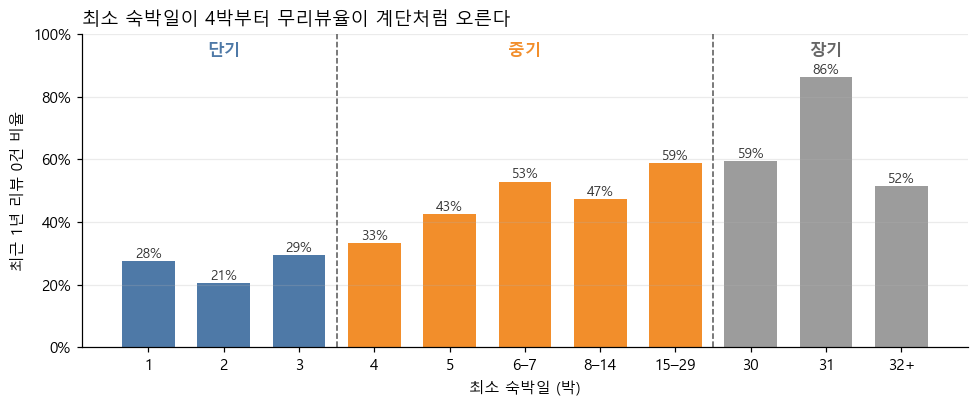

In [7]:
# [2-2] 최소 숙박일별 무리뷰율 — 경계는 데이터에서 보인다
mn = s["minimum_nights"]
bins = pd.cut(mn, [0, 1, 2, 3, 4, 5, 7, 14, 29, 30, 31, np.inf],
              labels=["1", "2", "3", "4", "5", "6–7", "8–14", "15–29", "30", "31", "32+"])
by_mn = s.groupby(bins).agg(매물=("norev", "size"), 무리뷰율=("norev", "mean"))
display(by_mn.T)

fig, ax = plt.subplots(figsize=(9, 3.8))
col = [C["main"]] * 3 + [C["accent"]] * 5 + [C["gray"]] * 3
ax.bar(by_mn.index.astype(str), by_mn["무리뷰율"], color=col, width=0.7)
for i, v in enumerate(by_mn["무리뷰율"]):
    ax.text(i, v + 0.01, f"{v:.0%}", ha="center", fontsize=9, color="#333")
ax.axvline(2.5, color="#555", lw=1, ls="--"); ax.axvline(7.5, color="#555", lw=1, ls="--")
ax.text(1, 0.93, "단기", ha="center", color=C["main"], fontsize=11, weight="bold")
ax.text(5, 0.93, "중기", ha="center", color=C["accent"], fontsize=11, weight="bold")
ax.text(9, 0.93, "장기", ha="center", color="#666", fontsize=11, weight="bold")
ax.set_ylim(0, 1); ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1))
ax.set_xlabel("최소 숙박일 (박)"); ax.set_ylabel("최근 1년 리뷰 0건 비율")
ax.set_title("최소 숙박일이 4박부터 무리뷰율이 계단처럼 오른다", loc="left")
ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

- **1–3박은 21–30%로 평평합니다.** 2박이 가장 낮습니다.
- **4박부터 오르기 시작해 5박 43%, 6–7박 53%** 입니다. 이전 결정 트리도 4.5박을 분기점으로 5회 모두 같게 골랐습니다(MODELING_RESULTS 3단계).
- **30박은 단기 숙박과 월 단위 임대를 가르는 관행적 경계**입니다. 31박은 무리뷰율 86%로 튑니다. 장기 셀 안에서는 "단기 예약 전환"이라는 같은 잣대로 평가하면 안 됩니다.

단, 이 표는 지역·가격을 통제하지 않은 값입니다. 통제 후에도 같은지는 5-2와 6장에서 확인합니다.

In [8]:
# [2-3] 최대 숙박일은 축이 될 수 없다 — 모든 셀이 365일 근처
s.groupby("cell")["maximum_nights"].describe(percentiles=[.25, .5, .75])[["25%", "50%", "75%"]].reindex(CELLS).T

cell,1번,2번,3번,4번,5번,6번
25%,99.000,59.000,305.000,99.000,31.000,365.000
50%,365.000,365.000,365.000,365.000,365.000,365.000
75%,"1,125.000","1,125.000","1,125.000",999.000,365.000,"1,125.000"


**최대 숙박일은 모든 셀의 중앙값이 365일**이고, 33.8%는 플랫폼 기본값(1,125일)입니다. 호스트가 의식적으로 설정한 값이 아니라 변별력이 없어 축에서 뺐습니다.

In [9]:
# [2-4] 예약 가능일 축이 필요 없는 이유 — source=0 에서는 거의 없다
print(pd.crosstab(s["availability_365"] == 0, s["cell"]).reindex(columns=CELLS))
print(f"\n예약 가능일 0: {(s.availability_365 == 0).sum():,}건 ({(s.availability_365 == 0).mean():.2%})")

cell                  1번     2번    3번      4번     5번     6번
availability_365                                           
False             418643  43259  9555  144542  33330  28349
True                 257     34     7     103     39     12

예약 가능일 0: 452건 (0.07%)


## 3. 2×3 표 — 셀별 프로필

In [10]:
# [3-1] 건수 · 비중 · 무리뷰율
ct = pd.crosstab(s["rev"], s["stay"]).reindex(columns=["단기", "중기", "장기"])
share = ct / len(s)
print("건수"); display(ct)
print("전체 대비 비중"); display(share.style.format("{:.1%}"))
print("최소 숙박 구간 안에서 무리뷰율"); display((ct.loc["X"] / ct.sum()).to_frame("무리뷰율").T.style.format("{:.1%}"))

건수


stay,단기,중기,장기
rev,,,
O,418900,43293,9562
X,144645,33369,28361


전체 대비 비중


stay,단기,중기,장기
rev,,,
O,61.8%,6.4%,1.4%
X,21.3%,4.9%,4.2%


최소 숙박 구간 안에서 무리뷰율


stay,단기,중기,장기
무리뷰율,25.7%,43.5%,74.8%


In [11]:
# [3-2] 동급 비교 · 계절성 — 모두 마스터 데이터의 컬럼이다 (scripts/build_master.py, 정의는 PREPROCESSING.md 4장)
# peer        : 도시 · 방 타입 · 인원(8명+는 8). 최소 숙박은 키에 넣지 않는다 — 넣으면 단기와 중기를 같은 조건에서 비교할 수 없다
# price_rel   : 동급 대비 가격 (log 가격의 동급 중앙값 기준, 1.13 = 13% 비쌈) · 그룹 30건 이상만
# amenity_rel : 동급 대비 편의시설 (동급 중앙값과의 차이)
# season_index: 지역별 (최근 30일 리뷰 × 12) ÷ 최근 1년 리뷰. 기준일이 7월이라 1보다 크면 여름 휴양지
s["p_rel"], s["a_rel"], s["seas"] = s["price_rel"], s["amenity_rel"], s["season_index"]
okp = s["has_price"] & ~s["flag_price_per_person_over_1000"]
s["lp"] = np.where(okp, np.log(s["price"]), np.nan)
seas = s.groupby("region")["season_index"].first()
print(f"동급 그룹 {s.loc[s['p_rel'].notna() | s['a_rel'].notna(), 'peer'].nunique():,}개 · 비교 가능 {s['p_rel'].notna().sum():,}건")

동급 그룹 653개 · 비교 가능 646,450건


In [12]:
# [3-3] 셀별 프로필
def profile(g):
    return pd.Series({
        "매물": len(g),
        "1박 가격 중앙값(€)": g["price"].median(),
        "동급 대비 가격": g["p_rel"].median(),
        "편의시설": g["amenity_count"].median(),
        "동급 대비 편의시설": g["a_rel"].median(),
        "수용 인원": g["accommodates"].median(),
        "침실": g["bedrooms"].median(),
        "통집 비율": g["entire"].mean(),
        "개인실 비율": (g["room_type"] == "Private room").mean(),
        "슈퍼호스트 비율": g["sh"].mean(),
        "할인 적용 비율": (~g["discount_type"].isin(["no_discount", "unknown"])).mean(),
        "누적 리뷰 0 비율": g["never"].mean(),
        "최근 1년 리뷰 중앙값": g["number_of_reviews_ltm"].median(),
        "호스트 경력 중앙값(년)": g["hosts_time_as_host_years"].median(),
        "호스트 경력 1년 미만": (g["hosts_time_as_host_years"] < 1).mean(),
        "1채만 보유한 호스트": (g["host_listings_total"] == 1).mean(),
        "21채+ 사업자": (g["host_listings_total"] >= 21).mean(),
        "예약 가능일(365)": g["availability_365"].median(),
        "계절성 지수": g["seas"].median(),
    })
prof = s.groupby("cell").apply(profile).reindex(CELLS).T
display(prof)

# 칸별로 가장 흔한 최소 숙박 설정 (상위 4개)
s.groupby("cell")["minimum_nights"].apply(
    lambda v: ", ".join(f"{k:.0f}박 {p:.0%}" for k, p in v.value_counts(normalize=True).head(4).items())
).reindex(CELLS).to_frame("주된 최소 숙박")

cell,1번,2번,3번,4번,5번,6번
매물,"418,900.000","43,293.000","9,562.000","144,645.000","33,369.000","28,361.000"
1박 가격 중앙값(€),153.200,177.000,75.570,167.000,206.000,92.175
동급 대비 가격,0.998,0.931,0.527,1.134,1.008,0.682
편의시설,35.000,36.000,30.000,25.000,27.000,19.000
동급 대비 편의시설,2.000,3.000,1.000,-6.000,-6.000,-9.000
수용 인원,4.000,4.000,2.000,4.000,4.000,3.000
침실,1.000,2.000,1.000,1.000,2.000,1.000
통집 비율,0.841,0.916,0.851,0.715,0.891,0.747
개인실 비율,0.153,0.083,0.147,0.270,0.107,0.249
슈퍼호스트 비율,0.410,0.346,0.363,0.116,0.118,0.072


,주된 최소 숙박
cell,
1번,"1박 54%, 2박 33%, 3박 13%"
2번,"4박 40%, 5박 27%, 7박 14%, 6박 7%"
3번,"30박 54%, 31박 32%, 32박 14%, 100박 0%"
4번,"1박 60%, 2박 24%, 3박 16%"
5번,"4박 26%, 5박 25%, 7박 23%, 6박 7%"
6번,"31박 68%, 30박 26%, 32박 5%, 90박 0%"


In [13]:
# [3-4] 칸별 상위 지역 — '지역 전체 매물(1–6번 합계) 중 이 칸의 비율'이 높은 지역 (지역 매물 2,000건 이상)
# 예: 부다페스트 전체 매물 10,349건 중 8,609건이 1번 → 83%.
# 반대 방향인 '이 칸 매물 중 그 지역의 비중'(구성비, 1번 중 부다페스트 2.1%)은 큰 도시가 항상 위에 오므로 쓰지 않는다.
reg = pd.crosstab(s["region"], s["cell"])[CELLS]
reg_share = reg.div(reg.sum(axis=1), axis=0)
base = s["cell"].value_counts(normalize=True)
big = reg.sum(axis=1) >= 2000
top = {c: ", ".join(f"{r} {reg_share.loc[r, c]:.0%}" for r in (reg_share.loc[big, c] / base[c]).nlargest(4).index)
       for c in CELLS}
pd.Series(top, name="지역 전체 매물 중 이 칸의 비율 (상위 4)").to_frame()

,지역 전체 매물 중 이 칸의 비율 (상위 4)
1번,"budapest 83%, sevilla 83%, venice 82%, prague 81%"
2번,"valencia 20%, menorca 20%, mallorca 17%, pays-basque 17%"
3번,"barcelona 17%, paris 6%, vienna 4%, madrid 4%"
4번,"puglia 35%, south-aegean 32%, sicily 31%, naples 30%"
5번,"pays-basque 11%, oslo 10%, stockholm 10%, vaud 9%"
6번,"barcelona 20%, sicily 12%, milan 11%, puglia 9%"


## 4. 셀 차이는 우연인가 — 전체 검정

표본이 67만 건이라 p값은 사실상 전부 0입니다. **효과 크기로 판단합니다** (Cramér V: 0.1 작음 · 0.3 중간 · 0.5 큼 / ε²: 0.01 작음 · 0.06 중간 · 0.14 큼).

In [14]:
# [4-1] 두 축은 서로 독립인가? + 셀 간 차이의 효과 크기
def cramers_v(a, b):
    t = pd.crosstab(a, b); chi2 = stats.chi2_contingency(t)[0]
    return chi2, np.sqrt(chi2 / (t.values.sum() * (min(t.shape) - 1)))

def kw_eps2(df, v):
    groups = [g[v].dropna().to_numpy() for _, g in df.groupby("cell")]
    H, p = stats.kruskal(*groups); n = sum(len(g) for g in groups)
    return H, (H - len(groups) + 1) / (n - len(groups))

chi2, V = cramers_v(s["rev"], s["stay"])
rows = [("최근 리뷰 O/X × 최소 숙박 구간", "카이제곱", chi2, V)]
for v, name in [("sh", "슈퍼호스트"), ("entire", "통집")]:
    sub = s.dropna(subset=[v]); c2, vv = cramers_v(sub["cell"], sub[v]); rows.append((name, "카이제곱", c2, vv))
for v, name in [("amenity_count", "편의시설"), ("accommodates", "수용 인원"), ("lp", "1박 가격(log)"), ("p_rel", "동급 대비 가격")]:
    H, e = kw_eps2(s, v); rows.append((name, "Kruskal-Wallis", H, e))
pd.DataFrame(rows, columns=["변수", "검정", "통계량", "효과 크기 (V 또는 ε²)"]).set_index("변수")

,검정,통계량,효과 크기 (V 또는 ε²)
변수,,,
최근 리뷰 O/X × 최소 숙박 구간,카이제곱,"47,491.878",0.265
슈퍼호스트,카이제곱,"58,485.700",0.294
통집,카이제곱,"16,691.730",0.157
편의시설,Kruskal-Wallis,"55,876.911",0.082
수용 인원,Kruskal-Wallis,"7,620.082",0.011
1박 가격(log),Kruskal-Wallis,"30,794.460",0.047
동급 대비 가격,Kruskal-Wallis,"37,998.612",0.059


- **두 축은 독립이 아닙니다(V 0.27, 중간).** 최소 숙박이 길수록 무리뷰가 많습니다. 축 하나만 보면 다른 축의 효과가 섞인다는 뜻이라 2×3으로 함께 봐야 합니다.
- 셀을 가장 강하게 가르는 것은 **슈퍼호스트와 편의시설(상품력)** 이고, 가격은 작습니다. 이전 5층 분석과 같은 결론입니다.

## 5. 셀별 painpoint 검정

손그림의 가설을 하나씩 검정합니다.

| 셀 | 손그림 가설 | 검정 |
|---|---|---|
| 4번 | 휴양지 · 비쌈 | 5-1 동급 비교 + 계절성 상관 |
| 5번 | 호스트 설정 문제 → 단기로 | 5-2 동급 그룹 내 비교 + 용량-반응 |
| 2번 | 럭셔리 · 가동률↓ — 문제가 있나? | 5-3 동급 내 가격·예약·매출 + 민감도 |
| 3번 | 장기 체류 · 수용 인원 적음 | 5-4 |
| 6번 | ? | 5-5 |
| X 전체 | 누적 리뷰도 0 vs 끊김 | 5-6 |

### 5-1. 4번 — "휴양지 · 비쌈"

In [15]:
# [5-1a] 같은 동급 그룹 안에서 4번 vs 1번
def mwu(a, b):
    a, b = a.dropna(), b.dropna(); U = stats.mannwhitneyu(a, b)[0]
    return 2 * U / (len(a) * len(b)) - 1          # 순위이연상관: +면 a가 큼

sh_ = s[s["stay"] == "단기"]
xs, os_ = sh_[sh_["rev"] == "X"], sh_[sh_["rev"] == "O"]
pd.DataFrame({
    "4번 중앙값": [xs["p_rel"].median(), xs["a_rel"].median(), (xs["p_rel"] > 1.6).mean(), (xs["a_rel"] <= -12).mean()],
    "1번 중앙값": [os_["p_rel"].median(), os_["a_rel"].median(), (os_["p_rel"] > 1.6).mean(), (os_["a_rel"] <= -12).mean()],
    "순위이연상관": [mwu(xs["p_rel"], os_["p_rel"]), mwu(xs["a_rel"], os_["a_rel"]), np.nan, np.nan],
}, index=["동급 대비 가격 (배)", "동급 대비 편의시설 (개)", "가격 1.6배 초과 비율", "편의시설 12개 이상 부족 비율"])

,4번 중앙값,1번 중앙값,순위이연상관
동급 대비 가격 (배),1.134,0.998,0.171
동급 대비 편의시설 (개),-6.000,2.000,-0.293
가격 1.6배 초과 비율,0.238,0.134,NaN
편의시설 12개 이상 부족 비율,0.347,0.150,NaN


지역 51개 · 계절성 지수 vs 단기 무리뷰율 순위상관 0.51 (p = 0.00015)


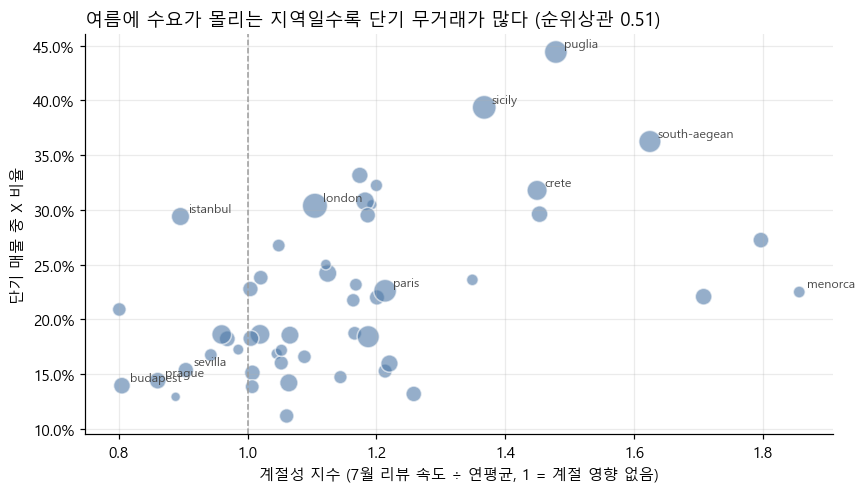

In [16]:
# [5-1b] 휴양지 가설 — 지역의 계절성이 클수록 단기 매물의 무리뷰율이 높은가 (매물 1,000건 이상 지역)
rg = sh_.groupby("region").agg(n=("norev", "size"), x_rate=("norev", "mean"), seas=("seas", "first"))
rg = rg[rg["n"] >= 1000]
rho, p = stats.spearmanr(rg["seas"], rg["x_rate"])
print(f"지역 {len(rg)}개 · 계절성 지수 vs 단기 무리뷰율 순위상관 {rho:.2f} (p = {p:.5f})")

fig, ax = plt.subplots(figsize=(8, 4.6))
ax.scatter(rg["seas"], rg["x_rate"], s=np.sqrt(rg["n"]) * 1.2, color=C["main"], alpha=0.6, edgecolor="white")
for r in ["puglia", "sicily", "south-aegean", "crete", "menorca", "budapest", "prague", "sevilla", "london", "paris", "istanbul"]:
    if r in rg.index:
        ax.annotate(r, (rg.loc[r, "seas"], rg.loc[r, "x_rate"]), xytext=(5, 3), textcoords="offset points", fontsize=8, color="#444")
ax.axvline(1, color=C["gray"], lw=1, ls="--")
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1))
ax.set_xlabel("계절성 지수 (7월 리뷰 속도 ÷ 연평균, 1 = 계절 영향 없음)")
ax.set_ylabel("단기 매물 중 X 비율")
ax.set_title(f"여름에 수요가 몰리는 지역일수록 단기 무거래가 많다 (순위상관 {rho:.2f})", loc="left")
plt.tight_layout(); plt.show()

**4번의 painpoint — 휴양지에서 동급보다 비싸고 상품력이 낮다**
- 같은 도시·방 타입·인원 안에서 **가격은 동급보다 13% 비싸고, 편의시설은 6개 적습니다.** 효과 크기는 편의시설(−0.29)이 가격(+0.17)보다 큽니다.
- **계절성 지수가 높은 지역일수록 단기 무거래가 많습니다(순위상관 0.51).** 풀리아·남에게해·시칠리아·크레타가 위쪽에 몰립니다. 짧은 성수기 수요에 비해 공급이 많은 것으로 보입니다.
- 6장 회귀에서 지역 계절성을 통제해도 가격·편의시설 효과가 남는지 확인합니다.

### 5-2. 5번 — "호스트 설정 문제"

비교 가능한 동급 그룹 298개 중 중기가 더 안 팔린 그룹 286개 (96%)
무리뷰율 차이 중앙값 +16.9%p · 부호 검정 p = 3.4e-69


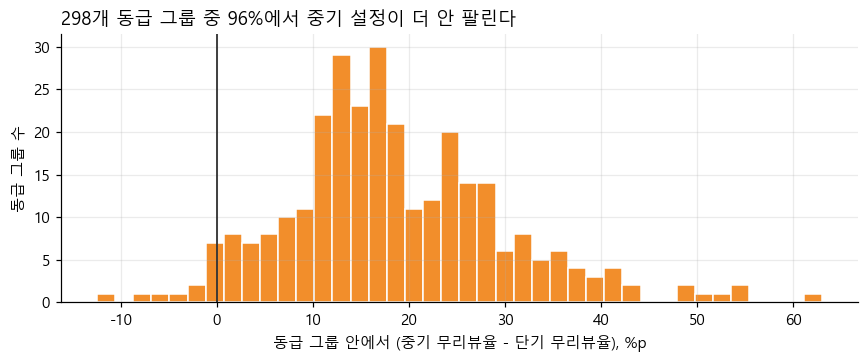

In [17]:
# [5-2a] 같은 동급 그룹 안에서 중기 vs 단기의 무리뷰율 — 그룹마다 비교 (양쪽 30건 이상)
u = s[s["stay"] != "장기"]
pg = u.groupby(["peer", "stay"])["norev"].agg(["mean", "size"]).unstack()
pg = pg[(pg[("size", "단기")] >= 30) & (pg[("size", "중기")] >= 30)]
diff = pg[("mean", "중기")] - pg[("mean", "단기")]
k = int((diff > 0).sum())
print(f"비교 가능한 동급 그룹 {len(diff)}개 중 중기가 더 안 팔린 그룹 {k}개 ({k / len(diff):.0%})")
print(f"무리뷰율 차이 중앙값 +{diff.median():.1%}p · 부호 검정 p = {stats.binomtest(k, len(diff)).pvalue:.1e}")

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.hist(diff * 100, bins=40, color=C["accent"], edgecolor="white")
ax.axvline(0, color="#333", lw=1.2)
ax.set_xlabel("동급 그룹 안에서 (중기 무리뷰율 - 단기 무리뷰율), %p")
ax.set_ylabel("동급 그룹 수")
ax.set_title(f"{len(diff)}개 동급 그룹 중 {k / len(diff):.0%}에서 중기 설정이 더 안 팔린다", loc="left")
plt.tight_layout(); plt.show()

In [18]:
# [5-2b] 시장 관행과 맞지 않아서인가? — 지역의 '거래 매물 중 중기 비율'(관행)별 중기 매물 무리뷰율
norm = s[s["rev"] == "O"].groupby("region")["stay"].apply(lambda v: (v == "중기").mean())
u = u.assign(mid_norm=u["region"].map(norm))
u["관행"] = pd.cut(u["mid_norm"], [0, .05, .10, .20, 1], labels=["중기 드묾 (<5%)", "5–10%", "10–20%", "중기 흔함 (20%+)"])
u.groupby(["관행", "stay"])["norev"].mean().unstack()[["단기", "중기"]].assign(차이=lambda t: t["중기"] - t["단기"])

stay,단기,중기,차이
관행,,,
중기 드묾 (<5%),0.184,0.389,0.204
5–10%,0.292,0.436,0.144
10–20%,0.292,0.468,0.176
중기 흔함 (20%+),0.233,0.342,0.109


**5번의 painpoint — 최소 숙박 설정이 예약을 막는다**
- **동급 그룹 298개 중 96%에서 중기가 단기보다 더 안 팔립니다.** 차이 중앙값 +17%p. 같은 도시·같은 방·같은 인원이라 지역이나 숙소 유형으로 설명되지 않습니다.
- **중기가 관행인 지역(발렌시아·마요르카·메노르카 등, 20%+)에서도 중기가 단기보다 10%p 더 안 팔립니다.** 관행과 무관하게 4박 이상 설정 자체가 불리합니다.
- 손그림의 "호스트 바보"는 발표에서는 **"설정 미스"** 로 표현하는 것을 권합니다. 6장에서 가격·상품력·지역을 통제한 용량-반응을 확인합니다.

### 5-3. 2번 — "럭셔리 · 가동률↓ — 문제가 있나?"

In [19]:
# [5-3a] 셀 전체로 보면 비싸다 — 그런데 동급 안에서 보면?
o = s[s["rev"] == "O"].copy()
o["nights"] = np.minimum(o["number_of_reviews_ltm"] / 0.5 * np.maximum(o["minimum_nights"], 3), 0.7 * 365)
o["revenue"] = o["nights"] * o["price"]
print(o.groupby("stay")[["price", "accommodates", "bedrooms", "number_of_reviews_ltm", "nights", "revenue"]].median()
      .reindex(["단기", "중기", "장기"]).rename(columns={"price": "1박 가격", "accommodates": "수용 인원", "bedrooms": "침실",
      "number_of_reviews_ltm": "최근1년 리뷰", "nights": "추정 숙박일", "revenue": "추정 연매출(€)"}).round(1))

og = o[o["stay"] != "장기"].groupby(["peer", "stay"]).agg(
    price=("price", "median"), ltm=("number_of_reviews_ltm", "median"), n=("id", "size")).unstack()
og = og[(og[("n", "단기")] >= 20) & (og[("n", "중기")] >= 20)]
for v, name in [("price", "1박 가격"), ("ltm", "최근 1년 리뷰(예약 수)")]:
    r = og[(v, "중기")] / og[(v, "단기")]
    print(f"동급 {len(og)}개 그룹 · {name} 중기/단기 중앙값 {r.median():.2f}배 · 중기가 높은 그룹 {(r > 1).mean():.0%}")

       1박 가격  수용 인원    침실  최근1년 리뷰  추정 숙박일  추정 연매출(€)
stay                                                 
단기   153.200  4.000 1.000    9.000  54.000  8,924.000
중기   177.000  4.000 2.000    4.000  40.000  7,488.200
장기    75.600  2.000 1.000    2.000 120.000  8,953.200
동급 285개 그룹 · 1박 가격 중기/단기 중앙값 0.90배 · 중기가 높은 그룹 18%
동급 285개 그룹 · 최근 1년 리뷰(예약 수) 중기/단기 중앙값 0.40배 · 중기가 높은 그룹 1%


In [20]:
# [5-3b] 매출로 보면? — 숙박 기간 가정에 따라 결론이 바뀐다
def rev_ratio(floor, mid_extra):
    stay_len = np.maximum(o["minimum_nights"], floor) + np.where(o["stay"] == "중기", mid_extra, 0)
    rv = np.minimum(o["number_of_reviews_ltm"] / 0.5 * stay_len, 0.7 * 365) * o["price"]
    g = o.assign(rv=rv)[o["stay"] != "장기"].groupby(["peer", "stay"]).agg(rv=("rv", "median"), n=("id", "size")).unstack()
    g = g[(g[("n", "단기")] >= 20) & (g[("n", "중기")] >= 20)]
    r = g[("rv", "중기")] / g[("rv", "단기")]
    return r.median(), (r < 1).mean()

sens = pd.DataFrame([(f, e, *rev_ratio(f, e)) for f, e in [(3, 0), (2, 0), (4, 0), (3, 1), (3, 2)]],
                    columns=["단기 최소 가정 숙박(박)", "중기 추가 숙박(박)", "매출 중기/단기", "중기가 낮은 그룹 비율"])
sens

,단기 최소 가정 숙박(박),중기 추가 숙박(박),매출 중기/단기,중기가 낮은 그룹 비율
0,3,0,0.733,0.775
1,2,0,1.032,0.460
2,4,0,0.559,0.972
3,3,1,0.848,0.607
4,3,2,0.984,0.519


**2번 — 문제라고 단정할 수 없습니다.**
- "럭셔리"는 **구성 효과**입니다. 셀 전체로는 비싸 보이지만(큰 집·휴양지 비중), **같은 동급 안에서는 1박 가격이 단기보다 오히려 10% 낮습니다**(할인 적용 비율 17% vs 6%).
- 예약 수는 동급 단기의 40% 수준이지만 한 번에 오래 묵습니다. **매출로 바꾸면 가정에 따라 0.56배~1.03배로 뒤집힙니다.** 단기 손님의 평균 숙박을 3박이 아니라 2박으로 보면 중기가 단기와 같습니다.
- 따라서 **2번은 painpoint가 아니라 "덜 자주, 길게 파는" 선택**입니다. 전략 대상에서 빼고, 손그림의 "문제가 큰가??"에 대한 답은 **"수치로는 문제라고 말할 수 없다"** 입니다.

### 5-4. 3번 — "장기 체류 · 수용 인원 적음"

In [21]:
# [5-4] 3번 vs 1번
ol, osh = o[o["stay"] == "장기"], o[o["stay"] == "단기"]
print(f"수용 인원 중앙값 {ol.accommodates.median():.0f} vs {osh.accommodates.median():.0f} · "
      f"2인 이하 비율 {(ol.accommodates <= 2).mean():.1%} vs {(osh.accommodates <= 2).mean():.1%} · "
      f"순위이연상관 {mwu(ol.accommodates, osh.accommodates):+.2f}")
print(f"21채+ 사업자 {(ol.host_listings_total >= 21).mean():.1%} vs {(osh.host_listings_total >= 21).mean():.1%}")
print(f"월 할인 적용 {(ol.discount_type == 'Monthly stay discount').mean():.1%}")
print(f"추정 연매출 중앙값 {ol.revenue.median():,.0f}€ vs {osh.revenue.median():,.0f}€")
reg_n = s["region"].value_counts()
loc = pd.DataFrame({"3번 매물": ol["region"].value_counts()}).head(5)
loc["3번 중 그 지역 비중 (구성비)"] = loc["3번 매물"] / len(ol)
loc["지역 전체 매물 중 3번 비율"] = loc["3번 매물"] / reg_n.reindex(loc.index)
loc["전체 대비 (배)"] = loc["지역 전체 매물 중 3번 비율"] / (len(ol) / len(s))
display(loc)

수용 인원 중앙값 2 vs 4 · 2인 이하 비율 56.5% vs 33.3% · 순위이연상관 -0.31
21채+ 사업자 31.7% vs 19.0%
월 할인 적용 48.4%
추정 연매출 중앙값 8,953€ vs 8,924€


,3번 매물,3번 중 그 지역 비중 (구성비),지역 전체 매물 중 3번 비율,전체 대비 (배)
region,,,,
paris,3078,0.322,0.064,4.546
barcelona,2193,0.229,0.168,11.934
madrid,724,0.076,0.039,2.774
milan,458,0.048,0.020,1.426
vienna,438,0.046,0.043,3.055


**3번 — painpoint 없음. 규제 도시의 장기 체류 상품이 제대로 돌아가는 칸입니다.**
- **2인 이하 소형이 57%** (단기 33%), 수용 인원 중앙값 2명. 손그림의 "수용 인원 적음"이 맞습니다. 출장·유학·이주 같은 1–2인 장기 체류 수요입니다.
- **바르셀로나는 전체 매물 13,032건 중 16.8%(2,193건)가 3번**으로, 전체 매물 중 3번 비율(1.4%)의 약 12배입니다. 파리 6.4%(약 4.5배), 마드리드 3.9%(약 2.8배)도 높습니다. 단기 임대 규제가 강한 도시에서 30박 이상으로 운영하는 형태로 보입니다(규제 내용은 외부 확인 필요).
- *3번 중 파리 비중*은 32%로 가장 크지만, 이는 파리 매물이 원래 많아서(48,021건)이기도 합니다. 지역 특성은 지역 내 비율로 판단합니다.
- 추정 연매출은 단기와 비슷하고, 대형 사업자 비중이 높습니다(32% vs 19%).

### 5-5. 6번 — "?"

,장기매물,팔리는비율,편의시설,계절성
region,,,,
puglia,4272,0.021,16.000,1.479
sicily,6797,0.046,18.000,1.367
naples,1045,0.092,17.000,1.174
rome,1876,0.148,18.000,1.187
milan,2909,0.157,19.000,0.960
florence,618,0.189,20.000,1.220
london,630,0.194,25.000,1.105
bologna,379,0.203,17.000,1.144
girona,331,0.248,24.000,1.182


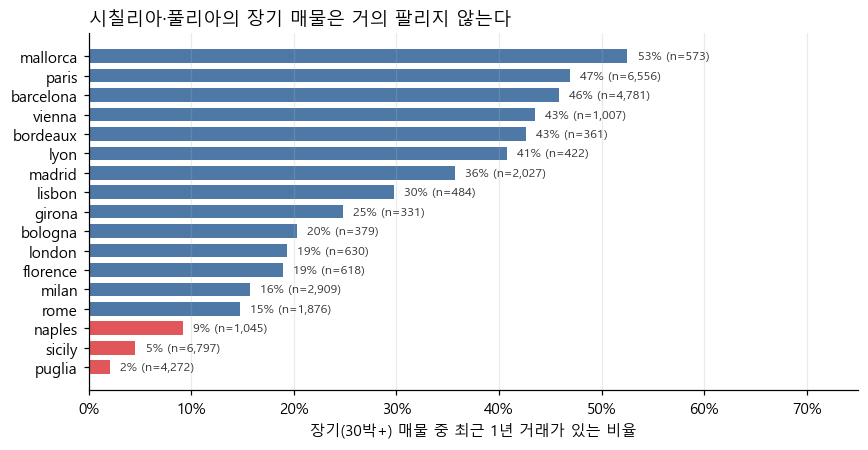

In [22]:
# [5-5a] 지역의 장기 매물(3번+6번) 중 팔리는 비율(3번) — 지역별로 극단적으로 갈린다 (장기 매물 300건 이상 지역)
L = s[s["stay"] == "장기"]
lr = L.groupby("region").agg(장기매물=("norev", "size"), 팔리는비율=("norev", lambda v: 1 - v.mean()),
                             편의시설=("amenity_count", "median"), 계절성=("seas", "first"))
lr = lr[lr["장기매물"] >= 300].sort_values("팔리는비율")
display(lr)

fig, ax = plt.subplots(figsize=(8, 4.2))
col = [C["bad"] if r in ("sicily", "puglia", "naples") else C["main"] for r in lr.index]
ax.barh(lr.index, lr["팔리는비율"], color=col, height=0.7)
for i, (v, n_) in enumerate(zip(lr["팔리는비율"], lr["장기매물"])):
    ax.text(v + 0.01, i, f"{v:.0%} (n={n_:,})", va="center", fontsize=8, color="#333")
ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(1)); ax.set_xlim(0, 0.75)
ax.set_xlabel("장기(30박+) 매물 중 최근 1년 거래가 있는 비율")
ax.set_title("시칠리아·풀리아의 장기 매물은 거의 팔리지 않는다", loc="left")
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

In [23]:
# [5-5b] 6번 두 유형 — 남부 이탈리아 휴양지 vs 그 밖(주로 도시)
SOUTH_IT = ["sicily", "puglia", "naples"]
xl = s[s["cell"] == "6번"].assign(유형=lambda t: np.where(t["region"].isin(SOUTH_IT), "남부 이탈리아 휴양지", "그 밖 (도시 중심)"))
ol2 = s[s["cell"] == "3번"].assign(유형="(참고) 3번")
pd.concat([xl, ol2]).groupby("유형").agg(
    매물=("id", "size"), 최소숙박=("minimum_nights", "median"), 가격=("price", "median"),
    편의시설=("amenity_count", "median"), 동급대비편의시설=("a_rel", "median"),
    슈퍼호스트=("sh", "mean"), 예약가능일=("availability_365", "median"), 누적리뷰0=("never", "mean")).T

유형,(참고) 3번,그 밖 (도시 중심),남부 이탈리아 휴양지
매물,"9,562.000","16,741.000","11,620.000"
최소숙박,30.000,31.000,31.000
가격,75.570,94.810,89.580
편의시설,30.000,22.000,16.000
동급대비편의시설,1.000,-8.000,-12.000
슈퍼호스트,0.363,0.104,0.025
예약가능일,247.000,272.000,362.000
누적리뷰0,0.000,0.662,0.519


In [24]:
# [5-5c] 과거에 팔렸던 6번은 언제 끊겼나
xl_l = xl[xl["number_of_reviews"] > 0]
print(f"6번 중 과거 거래 있음 {len(xl_l):,}건 · 마지막 리뷰 경과일 중앙값 {xl_l.days_since_last_review.median():.0f}일")

6번 중 과거 거래 있음 11,243건 · 마지막 리뷰 경과일 중앙값 995일


**6번 — 두 종류가 섞여 있습니다.**
- **남부 이탈리아 휴양지(시칠리아·풀리아·나폴리, 6번의 약 4할):** 장기 매물 중 팔리는 비율이 2–9%로 사실상 0입니다. 휴양지에는 한 달 체류 수요가 없는데 31박으로 걸려 있고, **편의시설 16–18개 · 슈퍼호스트 2–3% · 연중 362일 열려 있음** — 관리되지 않는 방치 재고에 가깝습니다. 이전 분석에서 이 지역의 30박+는 규제선이 아니라 호스트의 임의 설정으로 확인됐습니다(SEGMENTATION L2).
- **그 밖(파리·바르셀로나·밀라노 등 도시):** 같은 도시의 3번은 팔리고 있습니다(파리·바르셀로나 장기 매물 중 팔리는 비율 46–47%). 수요는 있는데 **편의시설이 동급보다 적고 슈퍼호스트가 드문**, 즉 상품 경쟁력 문제입니다.
- 과거에 팔렸던 6번도 마지막 리뷰가 중앙값 약 1,000일(2.7년) 전입니다.

### 5-6. X 안에서 — "한 번도 안 팔림" vs "팔리다 끊김"

In [25]:
# [5-6] 누적 리뷰 0 (never) vs 과거 거래 있음 (lapsed)
xx = s[s["rev"] == "X"].assign(유형=lambda t: np.where(t["never"] == 1, "한 번도 안 팔림", "팔리다 끊김"))
xx.groupby(["stay", "유형"]).agg(
    매물=("id", "size"), 가격=("price", "median"), 동급대비가격=("p_rel", "median"), 편의시설=("amenity_count", "median"),
    호스트경력1년미만=("hosts_time_as_host_years", lambda v: (v < 1).mean()),
    호스트경력중앙=("hosts_time_as_host_years", "median"),
    마지막리뷰경과일=("days_since_last_review", "median")).reindex(["단기", "중기", "장기"], level=0)

매물      가격  동급대비가격   편의시설  호스트경력1년미만  호스트경력중앙  마지막리뷰경과일
stay 유형                                                                   
단기   팔리다 끊김     56187 162.000   1.118 29.000      0.000    7.000   737.000
     한 번도 안 팔림  88458 171.180   1.147 23.000      0.278    2.000       NaN
중기   팔리다 끊김     13488 194.430   0.981 32.000      0.000    8.000   795.000
     한 번도 안 팔림  19881 215.400   1.035 24.000      0.187    3.000       NaN
장기   팔리다 끊김     11243  87.610   0.645 24.000      0.000    7.000   995.000
     한 번도 안 팔림  17118  96.810   0.707 16.000      0.069    4.000       NaN

- X의 **약 60%는 개설 이후 한 번도 안 팔린 매물**입니다. 이 중 단기는 호스트 경력 1년 미만이 28%로, 일부는 **아직 팔릴 기회가 없었던 신규 매물**입니다 → 6장 모델에서는 제외합니다.
- "한 번도 안 팔림"이 "끊김"보다 **비싸고 편의시설이 적습니다.** 첫 예약을 못 받는 원인이 상품 설정에 있다는 정황입니다.
- 전략에서는 "한 번도 안 팔림 = 첫 예약 전환(온보딩)", "끊김 = 재활성화"로 메시지를 다르게 가져갈 수 있습니다.

## 6. 통합 모델 — 다른 요인을 통제해도 painpoint가 남는가

**대상**: 단기+중기 · 신규 매물(호스트 경력 1년 미만 & 누적 리뷰 0) 제외 · 동급 비교 가능 · 슈퍼호스트 확인됨
**목표 변수**: 최근 1년 리뷰 0건 (X)

⚠️ **슈퍼호스트는 통제 변수로만** 씁니다. 슈퍼호스트는 숙박 실적이 있어야 받는 자격이라 거래의 원인이자 결과입니다(역인과). 해석·전략 대상에서 뺍니다.

In [26]:
# [6-1] 데이터 + 편의시설 이름 체계 통제 (MODELING_RESULTS 2단계 견고성 참고)
OLD_NAMES = {"Washer", "Dryer", "TV", "Air conditioning", "Patio or balcony"}
NEW_PREFIX = ("Free washer", "Paid washer", "Free dryer", "Paid dryer", "AC - ", "Central air conditioning",
              "Private patio or balcony", "Shared patio or balcony", "TV with", "HDTV")
m = s[(s["stay"] != "장기") & ~s["new_listing"] & s["p_rel"].notna() & s["a_rel"].notna() & s["sh"].notna()].copy()
am = m["amenities"].map(json.loads)
m["schema_old"] = am.map(lambda a: any(x in OLD_NAMES for x in a)).astype(int)
m["schema_new"] = am.map(lambda a: any(x.startswith(NEW_PREFIX) for x in a)).astype(int)
y = m["norev"]
X = pd.DataFrame({
    "중기 설정 (4–29박)": (m["stay"] == "중기").astype(int),
    "동급 대비 가격 (log)": np.log(m["p_rel"]),
    "동급 대비 편의시설 (+5개)": m["a_rel"] / 5,
    "지역 계절성 지수 (+1)": m["seas"],
    "통집": m["entire"],
    "슈퍼호스트 (통제)": m["sh"],
    "옛 이름 체계 (통제)": m["schema_old"],
    "새 이름 체계 (통제)": m["schema_new"],
})
print(f"표본 {len(m):,}건 · X 비율 {y.mean():.1%}")

표본 585,601건 · X 비율 23.6%


In [27]:
# [6-2] 로지스틱 회귀 + 오즈비 95% 신뢰구간 (표준오차는 피셔 정보행렬에서)
def fit_logit(X, y):
    model = LogisticRegression(penalty=None, max_iter=5000).fit(X, y)
    p = model.predict_proba(X)[:, 1]
    Xd = np.column_stack([np.ones(len(X)), X.to_numpy(dtype=float)])
    cov = np.linalg.inv(Xd.T @ (Xd * (p * (1 - p))[:, None]))
    return model, np.sqrt(np.diag(cov))[1:]

logit, se = fit_logit(X, y)
b = logit.coef_[0]
coef = pd.DataFrame({"계수": b, "오즈비": np.exp(b), "95% 하한": np.exp(b - 1.96 * se), "95% 상한": np.exp(b + 1.96 * se)},
                    index=X.columns)
Z = (X - X.mean()) / X.std()
coef["표준화 계수"] = LogisticRegression(penalty=None, max_iter=5000).fit(Z, y).coef_[0]
coef = coef.sort_values("표준화 계수", key=abs, ascending=False)
coef

,계수,오즈비,95% 하한,95% 상한,표준화 계수
슈퍼호스트 (통제),-1.278,0.278,0.274,0.283,-0.609
동급 대비 가격 (log),0.892,2.441,2.408,2.473,0.438
동급 대비 편의시설 (+5개),-0.142,0.868,0.865,0.870,-0.408
통집,-0.841,0.431,0.424,0.438,-0.318
중기 설정 (4–29박),0.967,2.629,2.581,2.678,0.313
지역 계절성 지수 (+1),1.199,3.316,3.223,3.412,0.272
옛 이름 체계 (통제),0.265,1.304,1.277,1.331,0.100
새 이름 체계 (통제),-0.100,0.905,0.891,0.920,-0.050


In [28]:
# [6-3] 검증 — 도시 단위 5겹 (학습에 쓰지 않은 도시에서 평가) + 지역 고정효과 모델
city_auc = []
for tr, te in GroupKFold(n_splits=5).split(X, y, groups=m["region"]):
    mdl = LogisticRegression(penalty=None, max_iter=5000).fit(X.iloc[tr], y.iloc[tr])
    city_auc.append(roc_auc_score(y.iloc[te], mdl.predict_proba(X.iloc[te])[:, 1]))
print(f"도시 단위 5겹 AUC {np.mean(city_auc):.3f} (겹별 {', '.join(f'{a:.3f}' for a in city_auc)})")

# 계절성 지수 대신 지역 더미를 넣어 '같은 도시 안에서' 비교 — 핵심 오즈비가 유지되나
XF = pd.concat([X.drop(columns="지역 계절성 지수 (+1)"), pd.get_dummies(m["region"], drop_first=True, dtype=int)], axis=1)
fe = LogisticRegression(penalty=None, max_iter=5000).fit(XF, y)
fe_or = pd.Series(np.exp(fe.coef_[0][:X.shape[1] - 1]), index=X.columns.drop("지역 계절성 지수 (+1)"))
pd.DataFrame({"계절성 모델 오즈비": coef["오즈비"], "지역 고정효과 모델 오즈비": fe_or}).dropna()

도시 단위 5겹 AUC 0.754 (겹별 0.731, 0.761, 0.764, 0.738, 0.773)


,계절성 모델 오즈비,지역 고정효과 모델 오즈비
동급 대비 가격 (log),2.441,2.470
동급 대비 편의시설 (+5개),0.868,0.863
새 이름 체계 (통제),0.905,0.882
슈퍼호스트 (통제),0.278,0.272
옛 이름 체계 (통제),1.304,1.213
중기 설정 (4–29박),2.629,2.795
통집,0.431,0.432


,오즈비 (2박 대비),95% 하한,95% 상한,매물
1박,0.995,0.978,1.012,279073
3박,1.470,1.437,1.504,73331
4박,1.826,1.765,1.888,24130
5박,2.642,2.549,2.738,18355
6–7박,4.002,3.857,4.153,16755
8–29박,7.861,7.492,8.247,10372


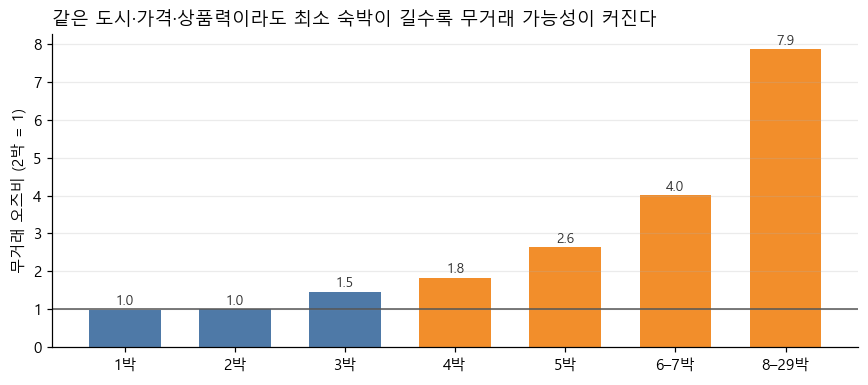

In [29]:
# [6-4] 최소 숙박일 용량-반응 — 2박 기준, 가격·편의시설·지역 고정효과 통제
Xd = X.drop(columns=["중기 설정 (4–29박)", "지역 계절성 지수 (+1)"]).copy()
DOSE = {"1박": (1, 1), "3박": (3, 3), "4박": (4, 4), "5박": (5, 5), "6–7박": (6, 7), "8–29박": (8, 29)}
for k_, (lo, hi) in DOSE.items():
    Xd[k_] = m["minimum_nights"].between(lo, hi).astype(int)
Xd = pd.concat([Xd, pd.get_dummies(m["region"], drop_first=True, dtype=int)], axis=1)
dm, dse = fit_logit(Xd, y)
idx = [list(Xd.columns).index(k_) for k_ in DOSE]
dose = pd.DataFrame({"오즈비 (2박 대비)": np.exp(dm.coef_[0][idx]),
                     "95% 하한": np.exp(dm.coef_[0][idx] - 1.96 * dse[idx]),
                     "95% 상한": np.exp(dm.coef_[0][idx] + 1.96 * dse[idx]),
                     "매물": [m["minimum_nights"].between(*DOSE[k_]).sum() for k_ in DOSE]}, index=list(DOSE))
display(dose)

fig, ax = plt.subplots(figsize=(8, 3.6))
xs_ = np.arange(len(dose) + 1); lab = ["1박", "2박"] + list(dose.index[1:])
vals = [dose.loc["1박", "오즈비 (2박 대비)"], 1.0] + list(dose["오즈비 (2박 대비)"].iloc[1:])
cols = [C["main"]] * 3 + [C["accent"]] * 4
ax.bar(xs_, vals, color=cols, width=0.65)
for i, v in enumerate(vals):
    ax.text(i, v + 0.12, f"{v:.1f}", ha="center", fontsize=9, color="#333")
ax.axhline(1, color="#555", lw=1)
ax.set_xticks(xs_, lab); ax.set_ylabel("무거래 오즈비 (2박 = 1)")
ax.set_title("같은 도시·가격·상품력이라도 최소 숙박이 길수록 무거래 가능성이 커진다", loc="left")
ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

In [30]:
# [6-5] 결정 트리 — 개입 기준선 (슈퍼호스트는 역인과라 제외, 깊이 3, 잎당 5,000건 이상)
T = pd.DataFrame({"최소 숙박일": m["minimum_nights"], "동급 대비 가격": m["p_rel"],
                  "동급 대비 편의시설": m["a_rel"], "지역 계절성 지수": m["seas"]})
tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=5000, random_state=SEED).fit(T, y)
print(export_text(tree, feature_names=list(T.columns), decimals=2))
print("중요도:", ", ".join(f"{k} {v:.2f}" for k, v in
      pd.Series(tree.feature_importances_, index=T.columns).sort_values(ascending=False).items()))

def leaf_rules(tree, names):
    t, rules = tree.tree_, {}
    def rec(node, conds):
        if t.children_left[node] == -1:
            rules[node] = " & ".join(conds); return
        f, th = names[t.feature[node]], t.threshold[node]
        rec(t.children_left[node], conds + [f"{f} ≤ {th:.2f}"])
        rec(t.children_right[node], conds + [f"{f} > {th:.2f}"])
    rec(0, []); return rules

leaf = pd.Series(tree.apply(T), index=T.index)
leaves = pd.DataFrame({"조건": pd.Series(leaf_rules(tree, list(T.columns))),
                       "매물": y.groupby(leaf).size(), "X 비율": y.groupby(leaf).mean()}).sort_values("X 비율", ascending=False)
print(f"전체 X 비율 {y.mean():.1%}")
leaves.reset_index(drop=True)

|--- 동급 대비 편의시설 <= -11.25
|   |--- 동급 대비 가격 <= 1.71
|   |   |--- 최소 숙박일 <= 4.50
|   |   |   |--- class: 0
|   |   |--- 최소 숙박일 >  4.50
|   |   |   |--- class: 1
|   |--- 동급 대비 가격 >  1.71
|   |   |--- 동급 대비 가격 <= 2.58
|   |   |   |--- class: 1
|   |   |--- 동급 대비 가격 >  2.58
|   |   |   |--- class: 1
|--- 동급 대비 편의시설 >  -11.25
|   |--- 동급 대비 가격 <= 2.08
|   |   |--- 지역 계절성 지수 <= 1.36
|   |   |   |--- class: 0
|   |   |--- 지역 계절성 지수 >  1.36
|   |   |   |--- class: 0
|   |--- 동급 대비 가격 >  2.08
|   |   |--- 동급 대비 가격 <= 3.60
|   |   |   |--- class: 0
|   |   |--- 동급 대비 가격 >  3.60
|   |   |   |--- class: 1

중요도: 동급 대비 편의시설 0.47, 동급 대비 가격 0.32, 지역 계절성 지수 0.12, 최소 숙박일 0.08
전체 X 비율 23.6%


,조건,매물,X 비율
0,동급 대비 편의시설 ≤ -11.25 & 동급 대비 가격 > 1.71 & 동급 대비 가격 > 2.58,6215,0.764
1,동급 대비 편의시설 ≤ -11.25 & 동급 대비 가격 ≤ 1.71 & 최소 숙박일 > 4.50,10043,0.612
2,동급 대비 편의시설 ≤ -11.25 & 동급 대비 가격 > 1.71 & 동급 대비 가격 ≤ 2.58,9829,0.563
3,동급 대비 편의시설 > -11.25 & 동급 대비 가격 > 2.08 & 동급 대비 가격 > 3.60,8457,0.532
4,동급 대비 편의시설 ≤ -11.25 & 동급 대비 가격 ≤ 1.71 & 최소 숙박일 ≤ 4.50,88338,0.341
5,동급 대비 편의시설 > -11.25 & 동급 대비 가격 > 2.08 & 동급 대비 가격 ≤ 3.60,29148,0.335
6,동급 대비 편의시설 > -11.25 & 동급 대비 가격 ≤ 2.08 & 지역 계절성 지수 > 1.36,116734,0.261
7,동급 대비 편의시설 > -11.25 & 동급 대비 가격 ≤ 2.08 & 지역 계절성 지수 ≤ 1.36,316837,0.149


## 7. 6칸 전체 검증 — 1–6번 카드의 특징이 모두 성립하는가

6장의 모델은 단기·중기(1·2·4·5번)만 다루고, 4·5번의 painpoint만 증명합니다. 여기서는 **6칸 전체**를 대상으로 다섯 가지를 확인합니다.

| | 검증 | 질문 |
|---|---|---|
| 7-1 | 칸 vs 나머지 효과 크기 | 카드에 적은 특징 하나하나가 통계적으로 성립하나 |
| 7-2 | 도시별 재현 | 그 특징이 몇 개 도시에서 똑같이 나타나나 |
| 7-3 | 칸 예측 모델 | 축 변수 없이 상품 특징만으로 칸을 가를 수 있나 |
| 7-4 | 6번 검정 | 장기 매물 안에서 "남부 이탈리아 + 상품력 부족"이 무거래와 연관되나 |
| 7-5 | 2번 vs 5번 | 편의시설이 좋으면 중기 설정의 불리함이 사라지나 |

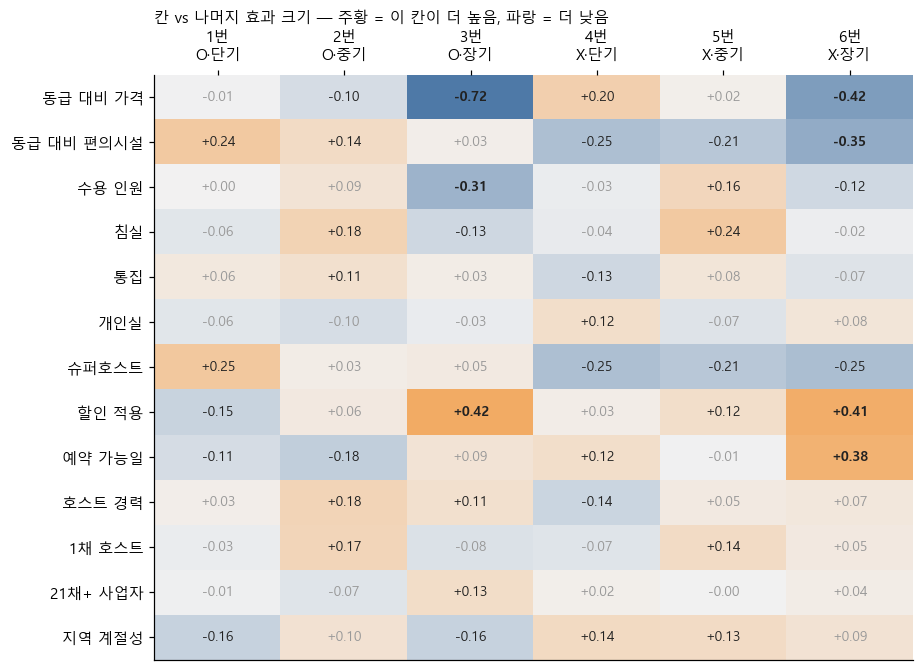

In [31]:
# [7-1] 칸 vs 나머지 — 순위이연상관 (−1~+1). 이진 변수는 '비율 차이'와 같다.
# 크기 기준: |r| < 0.1 무시 · 0.1–0.3 작음 · 0.3–0.5 중간 · 0.5+ 큼
s["private"] = (s["room_type"] == "Private room").astype(int)
s["disc"] = (~s["discount_type"].isin(["no_discount", "unknown"])).astype(int)
s["single"] = np.where(s["host_listings_total"].isna(), np.nan, (s["host_listings_total"] == 1).astype(float))
s["pro21"] = np.where(s["host_listings_total"].isna(), np.nan, (s["host_listings_total"] >= 21).astype(float))
s["lp_rel"] = np.log(s["p_rel"])
METRICS = {"동급 대비 가격": "lp_rel", "동급 대비 편의시설": "a_rel", "수용 인원": "accommodates", "침실": "bedrooms",
           "통집": "entire", "개인실": "private", "슈퍼호스트": "sh", "할인 적용": "disc", "예약 가능일": "availability_365",
           "호스트 경력": "hosts_time_as_host_years", "1채 호스트": "single", "21채+ 사업자": "pro21", "지역 계절성": "seas"}

def rank_biserial_vs_rest(v):
    x = s[[v, "cell"]].dropna()
    r = stats.rankdata(x[v]); n = float(len(x)); out = {}
    for c in CELLS:
        mask = (x["cell"] == c).to_numpy(); n1 = float(mask.sum()); n2 = n - n1   # float: Windows int32 overflow 방지
        U = r[mask].sum() - n1 * (n1 + 1) / 2
        out[c] = 2 * U / (n1 * n2) - 1
    return out

eff = pd.DataFrame({k: rank_biserial_vs_rest(v) for k, v in METRICS.items()}).T[CELLS]

fig, ax = plt.subplots(figsize=(8.5, 6.2))
cmap = mpl.colors.LinearSegmentedColormap.from_list("div", [C["main"], "#F2F2F2", C["accent"]])
ax.imshow(eff.to_numpy(), cmap=cmap, vmin=-0.6, vmax=0.6, aspect="auto")
for i in range(eff.shape[0]):
    for j in range(eff.shape[1]):
        v = eff.iat[i, j]
        ax.text(j, i, f"{v:+.2f}", ha="center", va="center", fontsize=9,
                color="#222" if abs(v) >= 0.1 else "#999", weight="bold" if abs(v) >= 0.3 else "normal")
ax.set_xticks(range(6), [f"{c}\n{l}" for c, l in zip(CELLS, ["O·단기", "O·중기", "O·장기", "X·단기", "X·중기", "X·장기"])])
ax.set_yticks(range(len(eff)), eff.index)
ax.tick_params(axis="x", top=True, bottom=False, labeltop=True, labelbottom=False)
ax.grid(False)
ax.set_title("칸 vs 나머지 효과 크기 — 주황 = 이 칸이 더 높음, 파랑 = 더 낮음", loc="left", fontsize=10, pad=34)
plt.tight_layout(); plt.show()

**읽는 법** — 한 칸(열)을 나머지 다섯 칸 전체와 비교한 값입니다. 0.1 미만은 회색(무시), 0.3 이상은 굵게(중간 이상) 표시했습니다.
카드별 핵심 특징이 모두 0.1 이상으로 성립합니다. 가장 큰 차이는 **3번의 낮은 가격(−0.72, 월 할인)** · **3번·6번의 할인(+0.4)** · **6번의 낮은 편의시설(−0.35)과 긴 예약 가능일(+0.38)** · **3번의 적은 인원(−0.31)** 입니다.

In [32]:
# [7-2] 도시별 재현 — 칸 사이 특징 차이가 몇 개 지역에서 같은 방향으로 나타나나 (두 칸 모두 30건 이상인 지역)
def regional(a, b, v, how, op):
    hits = []
    for _, g in s.groupby("region"):
        ga, gb = g.loc[g["cell"] == a, v].dropna(), g.loc[g["cell"] == b, v].dropna()
        if len(ga) >= 30 and len(gb) >= 30:
            fa, fb = (ga.median(), gb.median()) if how == "median" else (ga.mean(), gb.mean())
            hits.append(fa < fb if op == "<" else fa > fb)
    k, n = int(sum(hits)), len(hits)
    return k, n, stats.binomtest(k, n).pvalue

CHECKS = [
    ("4번", "편의시설이 1번보다 적다 (동급 대비)", "4번", "1번", "a_rel", "median", "<"),
    ("4번", "가격이 1번보다 높다 (동급 대비)", "4번", "1번", "p_rel", "median", ">"),
    ("4번", "슈퍼호스트가 1번보다 적다", "4번", "1번", "sh", "mean", "<"),
    ("5번", "편의시설이 2번보다 적다 (동급 대비)", "5번", "2번", "a_rel", "median", "<"),
    ("5번", "슈퍼호스트가 2번보다 적다", "5번", "2번", "sh", "mean", "<"),
    ("6번", "편의시설이 3번보다 적다 (동급 대비)", "6번", "3번", "a_rel", "median", "<"),
    ("6번", "슈퍼호스트가 3번보다 적다", "6번", "3번", "sh", "mean", "<"),
    ("3번", "수용 인원이 1번보다 적다", "3번", "1번", "accommodates", "mean", "<"),
    ("2번", "가격이 1번보다 낮다 (동급 대비)", "2번", "1번", "p_rel", "median", "<"),
    ("2번", "침실이 1번보다 많다", "2번", "1번", "bedrooms", "mean", ">"),
]
rows = []
for cell_, claim, a, b, v, how, op in CHECKS:
    k, n, p = regional(a, b, v, how, op)
    rows.append((cell_, claim, f"{k}/{n}", k / n, p))
# 중기가 단기보다 더 안 팔린다 (지역 안 무리뷰율, 중기 30건 이상)
hits = [g.loc[g["stay"] == "중기", "norev"].mean() > g.loc[g["stay"] == "단기", "norev"].mean()
        for _, g in s[s["stay"] != "장기"].groupby("region") if (g["stay"] == "중기").sum() >= 30]
rows.append(("4·5번", "중기 매물이 단기 매물보다 무거래 비율이 높다", f"{sum(hits)}/{len(hits)}", sum(hits) / len(hits),
             stats.binomtest(int(sum(hits)), len(hits)).pvalue))
pd.DataFrame(rows, columns=["칸", "특징", "성립 지역", "비율", "부호 검정 p"]).set_index(["칸", "특징"])

성립 지역    비율  부호 검정 p
칸    특징                                             
4번   편의시설이 1번보다 적다 (동급 대비)      53/53 1.000    0.000
     가격이 1번보다 높다 (동급 대비)        51/53 0.962    0.000
     슈퍼호스트가 1번보다 적다             53/53 1.000    0.000
5번   편의시설이 2번보다 적다 (동급 대비)      51/51 1.000    0.000
     슈퍼호스트가 2번보다 적다             51/51 1.000    0.000
6번   편의시설이 3번보다 적다 (동급 대비)      23/23 1.000    0.000
     슈퍼호스트가 3번보다 적다             26/26 1.000    0.000
3번   수용 인원이 1번보다 적다             26/27 0.963    0.000
2번   가격이 1번보다 낮다 (동급 대비)        49/53 0.925    0.000
     침실이 1번보다 많다                39/53 0.736    0.001
4·5번 중기 매물이 단기 매물보다 무거래 비율이 높다  53/53 1.000    0.000

**4·5·6번(안 팔리는 칸)이 같은 최소 숙박 구간의 O 칸보다 편의시설·슈퍼호스트가 적다는 것은 비교 가능한 모든 지역에서 예외 없이 성립합니다.** 중기가 단기보다 더 안 팔린다는 것도 53개 지역 전부에서 성립합니다.
2번의 "침실이 많다"만 74%로 상대적으로 약합니다 — 큰 집이 많은 것은 일부 휴양지 중심의 특징입니다.

In [33]:
# [7-3] 칸 예측 모델 — 축 변수(리뷰 수 · 최소 숙박)와 그 결과물(할인 유형 · 슈퍼호스트 · 예약 가능일)은 빼고,
#       상품·호스트·지역 특징만으로 1–6번을 맞힐 수 있나. 도시 단위 5겹(학습에 안 쓴 도시에서 평가)
FEAT = {"동급 대비 가격(log)": "lp_rel", "동급 대비 편의시설": "a_rel", "수용 인원": "accommodates", "침실": "bedrooms",
        "통집": "entire", "호스트 경력": "hosts_time_as_host_years", "호스트 보유 매물": "host_listings_total", "지역 계절성": "seas"}
bdf = s.dropna(subset=list(FEAT.values())).copy()
Xb, yb = bdf[list(FEAT.values())].to_numpy(), bdf["cell"].to_numpy()
prob = np.zeros((len(bdf), 6))
for tr, te in GroupKFold(n_splits=5).split(Xb, yb, groups=bdf["region"]):
    clf = DecisionTreeClassifier(max_depth=6, min_samples_leaf=500, class_weight="balanced", random_state=SEED).fit(Xb[tr], yb[tr])
    prob[te] = clf.predict_proba(Xb[te])            # classes_ 는 CELLS 순서와 같다 ("1번" … "6번")
auc_cell = pd.Series({c: roc_auc_score(yb == c, prob[:, i]) for i, c in enumerate(CELLS)}, name="칸별 AUC (이 칸 vs 나머지)")
clf = DecisionTreeClassifier(max_depth=6, min_samples_leaf=500, class_weight="balanced", random_state=SEED).fit(Xb, yb)
print(f"표본 {len(bdf):,}건")
display(auc_cell.to_frame().T)
pd.Series(clf.feature_importances_, index=list(FEAT)).sort_values(ascending=False).to_frame("중요도").T

표본 630,482건


,1번,2번,3번,4번,5번,6번
칸별 AUC (이 칸 vs 나머지),0.637,0.603,0.802,0.629,0.610,0.607


,동급 대비 가격(log),지역 계절성,동급 대비 편의시설,호스트 보유 매물,통집,침실,수용 인원,호스트 경력
중요도,0.370,0.258,0.130,0.068,0.058,0.049,0.034,0.033


**상품·호스트·지역 특징만으로도 모든 칸을 우연(0.5)보다 잘 가릅니다.** 3번(0.80)은 뚜렷이 구분되고, 나머지는 0.61–0.64로 중간입니다.
해석: 칸 사이에는 실제 상품 차이가 있지만, **칸을 가르는 힘의 상당 부분은 상품이 아니라 설정(최소 숙박)과 거래 여부 자체**에 있습니다. "6칸은 상품이 완전히 다른 집단"이라고 과장하지 말고, "상품 특징이 칸마다 일관되게 다르다(7-1·7-2)"까지 주장하세요.

In [34]:
# [7-4] 6번 검정 — 장기 매물(3번+6번)만으로 로지스틱 회귀. 목표: 6번(무거래)
SOUTH_IT = ["sicily", "puglia", "naples"]
lg = s[(s["stay"] == "장기") & s["p_rel"].notna() & s["a_rel"].notna()].copy()
XL = pd.DataFrame({"남부 이탈리아 휴양지": lg["region"].isin(SOUTH_IT).astype(int),
                   "동급 대비 편의시설 (+5개)": lg["a_rel"] / 5,
                   "동급 대비 가격 (log)": np.log(lg["p_rel"]),
                   "통집": lg["entire"]})
yL = lg["norev"]
mL, seL = fit_logit(XL, yL)
bL = mL.coef_[0]
print(f"표본 {len(lg):,}건 · 6번 비율 {yL.mean():.1%}")
aucL = [roc_auc_score(yL.iloc[te], LogisticRegression(penalty=None, max_iter=5000).fit(XL.iloc[tr], yL.iloc[tr]).predict_proba(XL.iloc[te])[:, 1])
        for tr, te in GroupKFold(n_splits=5).split(XL, yL, groups=lg["region"])]
print(f"도시 단위 5겹 AUC {np.mean(aucL):.3f}")
# 남부 이탈리아를 빼고(도시형만) 다시 — 상품 경쟁력 효과가 남는가
ns = XL["남부 이탈리아 휴양지"] == 0
mN = LogisticRegression(penalty=None, max_iter=5000).fit(XL[ns].drop(columns="남부 이탈리아 휴양지"), yL[ns])
pd.DataFrame({"오즈비": np.exp(bL), "95% 하한": np.exp(bL - 1.96 * seL), "95% 상한": np.exp(bL + 1.96 * seL),
              "도시형만 오즈비": pd.Series(np.exp(mN.coef_[0]), index=XL.columns.drop("남부 이탈리아 휴양지"))},
             index=XL.columns)

표본 35,078건 · 6번 비율 73.8%
도시 단위 5겹 AUC 0.783


,오즈비,95% 하한,95% 상한,도시형만 오즈비
남부 이탈리아 휴양지,14.059,12.693,15.573,NaN
동급 대비 편의시설 (+5개),0.777,0.769,0.785,0.768
동급 대비 가격 (log),3.087,2.913,3.271,3.190
통집,0.454,0.422,0.488,0.447


**6번의 두 유형이 모두 수치로 성립합니다.**
- **남부 이탈리아 휴양지**는 같은 가격·편의시설이라도 무거래 오즈가 약 14배입니다 — 지역 자체에 장기 수요가 없습니다.
- **도시형만 따로 봐도** 편의시설 5개당 무거래 오즈 −23%, 동급보다 비쌀수록 무거래 — 상품 경쟁력 문제입니다.
- 학습에 쓰지 않은 도시에서도 AUC 0.78로 통합니다.

상호작용 오즈비 0.985 (95% CI 0.979–0.991)


stay,단기,중기,중기 ÷ 단기
a_rel,,,
−12개 이하,0.374,0.594,1.588
−11~−6,0.241,0.426,1.764
−5~0,0.200,0.368,1.844
+1~+6,0.166,0.326,1.971
+7개 이상,0.149,0.291,1.953


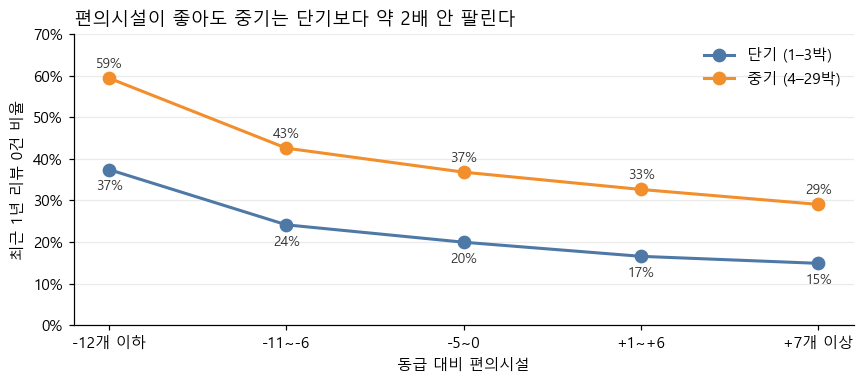

In [35]:
# [7-5] 2번 vs 5번 — 편의시설이 좋으면 중기 설정의 불리함이 사라지나? (6장 모델 + '중기 × 편의시설' 상호작용)
XI = X.assign(**{"중기 × 편의시설": X["중기 설정 (4–29박)"] * X["동급 대비 편의시설 (+5개)"]})
mI, seI = fit_logit(XI, y)
k_ = list(XI.columns).index("중기 × 편의시설")
print(f"상호작용 오즈비 {np.exp(mI.coef_[0][k_]):.3f} (95% CI {np.exp(mI.coef_[0][k_] - 1.96 * seI[k_]):.3f}–{np.exp(mI.coef_[0][k_] + 1.96 * seI[k_]):.3f})")

# 원자료 — 동급 대비 편의시설 구간별 무리뷰율, 단기 vs 중기
ab = pd.cut(m["a_rel"], [-np.inf, -12, -6, 0, 6, np.inf], labels=["−12개 이하", "−11~−6", "−5~0", "+1~+6", "+7개 이상"])
raw = m.groupby([ab, "stay"])["norev"].mean().unstack()[["단기", "중기"]]
raw["중기 ÷ 단기"] = raw["중기"] / raw["단기"]
display(raw)

fig, ax = plt.subplots(figsize=(8, 3.6))
xi = np.arange(len(raw))
ax.plot(xi, raw["단기"], marker="o", lw=2, ms=8, color=C["main"], label="단기 (1–3박)")
ax.plot(xi, raw["중기"], marker="o", lw=2, ms=8, color=C["accent"], label="중기 (4–29박)")
for i in xi:
    ax.text(i, raw["중기"].iloc[i] + 0.025, f"{raw['중기'].iloc[i]:.0%}", ha="center", fontsize=9, color="#333")
    ax.text(i, raw["단기"].iloc[i] - 0.05, f"{raw['단기'].iloc[i]:.0%}", ha="center", fontsize=9, color="#333")
ax.set_xticks(xi, [str(v).replace("−", "-") for v in raw.index]); ax.set_xlabel("동급 대비 편의시설")
ax.set_ylim(0, 0.7); ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1)); ax.set_ylabel("최근 1년 리뷰 0건 비율")
ax.legend(frameon=False, loc="upper right")
ax.set_title("편의시설이 좋아도 중기는 단기보다 약 2배 안 팔린다", loc="left")
ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

**"중기 설정은 상품이 받쳐 줄 때만 통한다"는 성립하지 않습니다.** 상호작용은 통계적으로 0이 아니지만 크기가 거의 없고(오즈비 0.985), 편의시설이 동급보다 7개 이상 많아도 중기는 단기보다 약 2배 안 팔립니다. 배수로 보면 오히려 편의시설이 좋을수록 1.6배 → 2.0배로 커집니다.
편의시설과 최소 숙박은 **각자 따로** 작용합니다. 2번이 팔리는 이유는 "중기가 상품 덕에 통해서"가 아니라 **상품력이 좋아 중기의 불리함을 일부 상쇄하기 때문**입니다.
이 결과는 5번 처방을 강화합니다 — 상품을 고쳐도 중기 설정의 불리함은 남으므로, **최소 숙박 하향은 편의시설 보완과 별개로 필요합니다.**

## 8. 요약 — 셀 · painpoint · 근거 · 전략 방향

In [36]:
# [8-1] 요약 표에 들어가는 숫자
summary = pd.DataFrame({
    "매물": s["cell"].value_counts().reindex(CELLS),
    "비중": s["cell"].value_counts(normalize=True).reindex(CELLS),
}).join(prof.T[["1박 가격 중앙값(€)", "동급 대비 가격", "동급 대비 편의시설", "수용 인원", "슈퍼호스트 비율", "계절성 지수"]])
summary

,매물,비중,1박 가격 중앙값(€),동급 대비 가격,동급 대비 편의시설,수용 인원,슈퍼호스트 비율,계절성 지수
cell,,,,,,,,
1번,418900,0.618,153.200,0.998,2.000,4.000,0.410,1.166
2번,43293,0.064,177.000,0.931,3.000,4.000,0.346,1.187
3번,9562,0.014,75.570,0.527,1.000,2.000,0.363,1.144
4번,144645,0.213,167.000,1.134,-6.000,4.000,0.116,1.187
5번,33369,0.049,206.000,1.008,-6.000,4.000,0.118,1.200
6번,28361,0.042,92.175,0.682,-9.000,3.000,0.072,1.214
